# Shipment Risk Analysis & Prediction

### Project Objective
The objective of this project is to analyze shipment data to identify factors causing delivery delays and build a machine learning model to predict late deliveries. It focuses on detecting high-risk shipments and providing actionable insights through a Power BI dashboard to improve supply chain efficiency and decision-making.

### Dataset Overview
The dataset used in this project is the DataCo Smart Supply Chain dataset, which contains detailed information about customer orders, shipping operations, product categories, and delivery performance.

It includes over 180,000 records with more than 50 features covering various aspects such as:

Order and shipping dates
Delivery status and delay indicators
Shipping modes and regions
Product categories and pricing
Customer location and segmentation

Key variables used in the analysis include shipping duration, scheduled vs actual delivery time, shipping mode, sales metrics, and late delivery risk indicators.

The dataset provides a comprehensive view of supply chain operations, enabling both exploratory analysis and predictive modeling to uncover insights and improve delivery efficiency.

### Stage1 : Data Analysis

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\HP\Downloads\SupplySync\data\raw\DataCoSupplyChainDataset.csv', encoding = 'latin1')

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [5]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


##### Column to drop

In [6]:
columns_to_drop = [
    'Product Description',      # Completely empty
    'Customer Email',           # Sensitive information
    'Customer Password',        # Sensitive information
    'Customer Fname',           # Not useful for analytics
    'Customer Lname',           # Not useful for analytics
    'Customer Street',          # Too granular
    'Product Image'             # URL, no analytical value
]

df.drop(columns=columns_to_drop, inplace=True)

In [7]:
print(f"Remaining Columns: {df.shape[1]}")
df.head()

Remaining Columns: 46


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [8]:
# Handle missing values
# Fill missing Customer Zipcode with median
# Fill missing values
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(
    df['Customer Zipcode'].median()
)

# Drop column only if it exists
if 'Order Zipcode' in df.columns:
    df.drop('Order Zipcode', axis=1, inplace=True)

print(f"Updated Shape: {df.shape}")


Updated Shape: (180519, 45)


In [9]:
#convert date to columns
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)']
)

In [10]:
# Verify data types
print(df[['order date (DateOrders)',
          'shipping date (DateOrders)']].dtypes)

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object


In [11]:
# Extract order date features
df['Order Year'] = df['order date (DateOrders)'].dt.year
df['Order Month'] = df['order date (DateOrders)'].dt.month
df['Order Day'] = df['order date (DateOrders)'].dt.day
df['Order Weekday'] = df['order date (DateOrders)'].dt.day_name


In [12]:
# Preview new columns
df[['order date (DateOrders)',
    'Order Year',
    'Order Month',
    'Order Day',
    'Order Weekday']].head()

,order date (DateOrders),Order Year,Order Month,Order Day,Order Weekday
0,2018-01-31 22:56:00,2018,1,31,<bound method PandasDelegate._add_delegate_acc...
1,2018-01-13 12:27:00,2018,1,13,<bound method PandasDelegate._add_delegate_acc...
2,2018-01-13 12:06:00,2018,1,13,<bound method PandasDelegate._add_delegate_acc...
3,2018-01-13 11:45:00,2018,1,13,<bound method PandasDelegate._add_delegate_acc...
4,2018-01-13 11:24:00,2018,1,13,<bound method PandasDelegate._add_delegate_acc...


In [13]:
df['Order Weekday'] = df['order date (DateOrders)'].dt.day_name()

In [14]:
df[['order date (DateOrders)',
    'Order Year',
    'Order Month',
    'Order Day',
    'Order Weekday']].head()

,order date (DateOrders),Order Year,Order Month,Order Day,Order Weekday
0,2018-01-31 22:56:00,2018,1,31,Wednesday
1,2018-01-13 12:27:00,2018,1,13,Saturday
2,2018-01-13 12:06:00,2018,1,13,Saturday
3,2018-01-13 11:45:00,2018,1,13,Saturday
4,2018-01-13 11:24:00,2018,1,13,Saturday


In [15]:
#Creating shipping delay
df['Shipping Delay'] = (
    df['Days for shipping (real)'] -
    df['Days for shipment (scheduled)']
)

df[['Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Shipping Delay']].head()

,Days for shipping (real),Days for shipment (scheduled),Shipping Delay
0,3,4,-1
1,5,4,1
2,4,4,0
3,3,4,-1
4,2,4,-2


##### Create Delivery Performance Category

In [16]:
def delivery_performance(delay):
    if delay < 0:
        return 'Early'
    elif delay == 0:
        return 'On Time'
    else:
        return 'Late'

df['Delivery Performance'] = df['Shipping Delay'].apply(delivery_performance)

# Verify distribution
print(df['Delivery Performance'].value_counts())

Delivery Performance
Late       103400
Early       43366
On Time     33753
Name: count, dtype: int64


In [17]:
#Late Deliveries: 103,400 (~57%)
#Early Deliveries: 43,366 (~24%)
#On-Time Deliveries: 33,753 (~19%)

In [18]:
#Performing initial exploratory analysis
shipping_performance = pd.crosstab(
    df['Shipping Mode'],
    df['Delivery Performance']
)

shipping_performance

Delivery Performance,Early,Late,On Time
Shipping Mode,,,
First Class,0,27814,0
Same Day,0,4657,5080
Second Class,0,28078,7138
Standard Class,43366,42851,21535


<Axes: xlabel='Shipping Mode'>

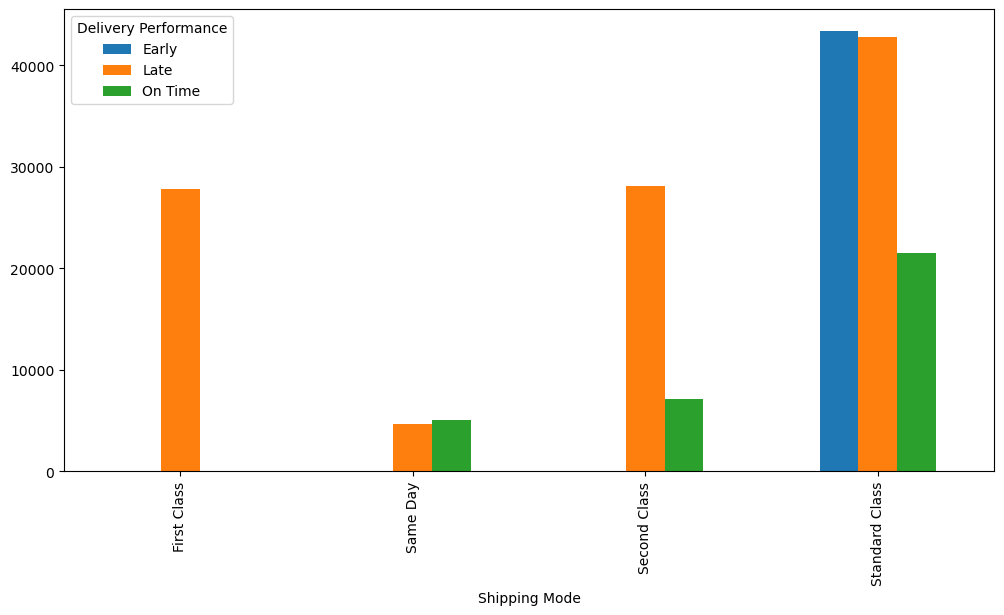

In [19]:
shipping_performance.plot(
    kind='bar',
    figsize=(12, 6)
)

In [20]:
#Calculating Late Delivery Percentage
late_percentage = (
    shipping_performance['Late'] /
    shipping_performance.sum(axis=1) * 100
).sort_values(ascending=False)

print(late_percentage)

Shipping Mode
First Class       100.000000
Second Class       79.730804
Same Day           47.827873
Standard Class     39.768171
dtype: float64


<Axes: title={'center': 'Late Delivery Percentage by Shipping Mode'}, xlabel='Shipping Mode'>

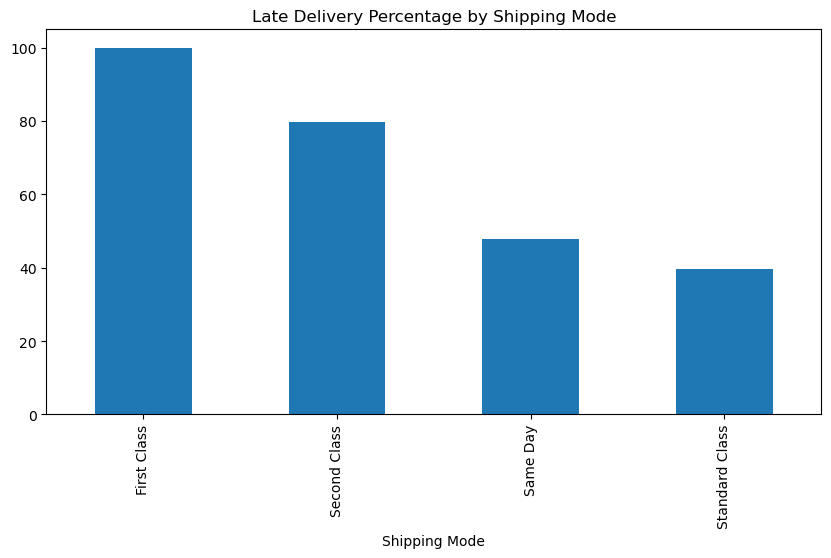

In [21]:
#Visualization
late_percentage.plot(
    kind='bar',
    figsize=(10, 5),
    title='Late Delivery Percentage by Shipping Mode'
)

## Late Delivery Rate by Shipping Mode Analysis

This analysis examines the delivery performance of different shipping modes to identify which methods are most prone to delays. By calculating the percentage of late deliveries for each shipping option, we can evaluate shipping reliability and uncover operational inefficiencies.

### Key Insights

- **First Class** recorded a **100% late delivery rate**, indicating a critical operational or data quality issue that requires immediate attention.
- **Second Class** showed a significantly high delay rate of **79.73%**, suggesting major inefficiencies in fulfillment or transportation processes.
- **Same Day** performed relatively better, with a late delivery rate of **47.83%**, though there is still considerable room for improvement.
- **Standard Class** emerged as the most reliable option, with the lowest delay rate of **39.77%**.

### Business Interpretation

Premium shipping options are expected to deliver faster, but they often face stricter service-level agreements, making delays more noticeable. The exceptionally high delay rate in First Class and Second Class indicates potential issues such as unrealistic promised delivery dates, carrier limitations, or operational bottlenecks.

Interestingly, Standard Class demonstrated the best reliability despite being the slowest option, highlighting the importance of setting realistic customer expectations.

### Recommendations

- Conduct an immediate audit of First Class delivery processes and SLA calculations.
- Reassess logistics workflows for Second Class shipments.
- Consider promoting Standard Class as a cost-effective and reliable shipping option.
- Implement predictive monitoring systems to identify high-risk shipments before delays occur.

### Impact

Improving shipping mode performance can significantly enhance customer satisfaction, reduce complaint rates, and optimize logistics costs while strengthening overall supply chain reliability.

In [22]:
#Analyze Delays by Product Category
category_performance = pd.crosstab(
    df['Category Name'],
    df['Delivery Performance']
)

category_performance['Late %'] = (
    category_performance['Late'] /
    category_performance.sum(axis=1) * 100
).round(2)

category_performance = category_performance.sort_values(
    'Late %',
    ascending=False
)

category_performance


Delivery Performance,Early,Late,On Time,Late %
Category Name,,,,
Golf Bags & Carts,12,42,7,68.85
Lacrosse,80,213,50,62.10
Cameras,129,367,96,61.99
Pet Supplies,95,302,95,61.38
Sporting Goods,87,214,56,59.94
Basketball,22,40,5,59.70
Fitness Accessories,72,184,53,59.55
Crafts,107,288,89,59.50
Strength Training,22,66,23,59.46


<Axes: title={'center': 'Late Delivery Percentage by Product Category'}, xlabel='Category Name'>

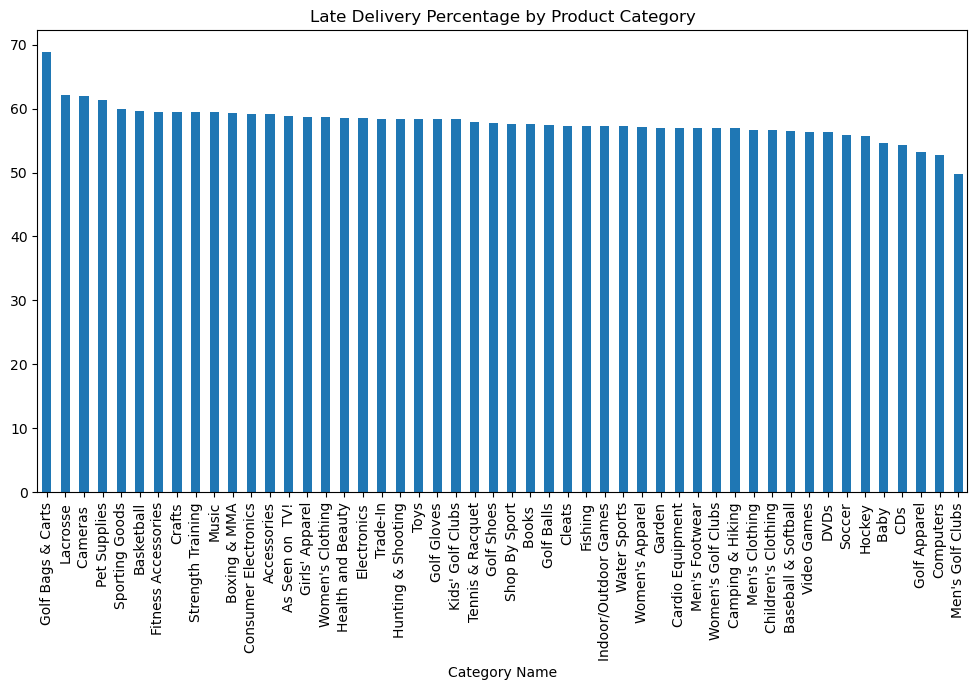

In [23]:
#Visualization
category_performance['Late %'].plot(
    kind='bar',
    figsize=(12, 6),
    title='Late Delivery Percentage by Product Category'
)

## Delivery Performance by Product Category Analysis

This analysis evaluates shipment performance across different product categories to identify which categories experience the highest delivery delays. By calculating the percentage of late deliveries for each category, we can uncover operational bottlenecks and supply chain inefficiencies.

### Key Insights

- **Golf Bags & Carts** recorded the highest late delivery rate at **68.85%**, indicating significant fulfillment or transportation challenges.
- Other categories with notably high delay rates include:
  - **Lacrosse** – 62.10%
  - **Cameras** – 61.99%
  - **Pet Supplies** – 61.38%
  - **Sporting Goods** – 59.94%

### Business Interpretation

Products with larger dimensions, special handling requirements, or higher demand often face greater logistical challenges. Categories such as golf equipment and cameras may require specialized packaging, careful transportation, or may be distributed from limited warehouse locations.

High delay rates in premium and essential product categories can negatively impact customer satisfaction, increase return rates, and reduce brand loyalty.

### Recommendations

- Optimize inventory placement for high-delay categories across multiple warehouses.
- Allocate reliable shipping carriers for premium and bulky items.
- Implement predictive delay alerts for categories with historically poor delivery performance.
- Continuously monitor category-level shipping KPIs to improve fulfillment efficiency.

### Impact

This analysis helps businesses prioritize operational improvements, enhance customer experience, and reduce revenue loss caused by delayed deliveries.

In [24]:
#Regional delay analysis
region_performance = pd.crosstab(
    df['Order Region'],
    df['Delivery Performance']
)

region_performance['Late %'] = (
    region_performance['Late'] /
    region_performance.sum(axis=1) * 100
).round(2)

region_performance = region_performance.sort_values(
    'Late %',
    ascending=False
)

region_performance

Delivery Performance,Early,Late,On Time,Late %
Order Region,,,,
Central Africa,359,1018,300,60.70
Western Europe,6402,15863,4844,58.52
South Asia,1829,4523,1379,58.50
South of USA,975,2350,720,58.10
East of USA,1627,4009,1279,57.98
Southeast Asia,2301,5531,1707,57.98
West Asia,1381,3455,1173,57.50
East Africa,422,1064,366,57.45
Eastern Europe,913,2252,755,57.45


<Axes: title={'center': 'Late Delivery Percentage by Region'}, xlabel='Order Region'>

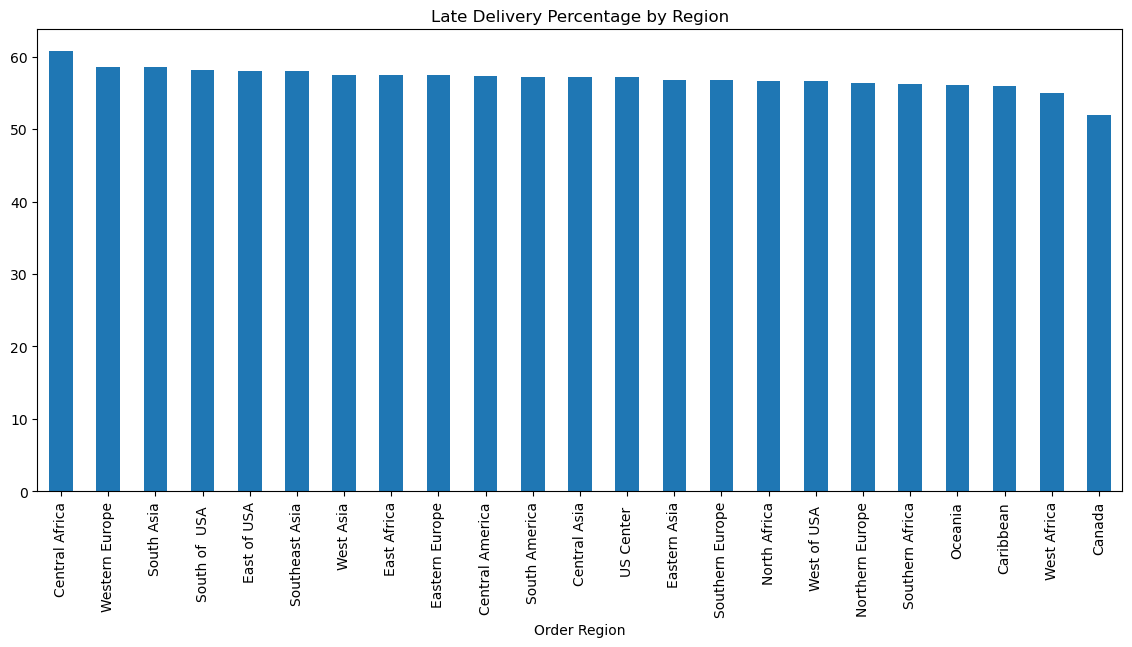

In [25]:
#Visualization
region_performance['Late %'].plot(
    kind='bar',
    figsize=(14, 6),
    title='Late Delivery Percentage by Region'
)

## Regional Delivery Performance Analysis

This analysis examines delivery performance across different geographic regions to identify areas experiencing the highest rates of shipment delays. Understanding regional inefficiencies helps businesses optimize logistics operations, improve customer satisfaction, and allocate resources more effectively.

### Key Insights

- **Central Africa** recorded the highest late delivery rate at **60.70%**, making it the most challenging region for timely deliveries.
- Other regions with elevated delay rates include:
  - **Western Europe** – 58.52%
  - **South Asia** – 58.50%
  - **South of USA** – 58.10%
  - **East of USA** – 57.98%
  - **Southeast Asia** – 57.98%

- **Canada** demonstrated the best delivery performance, with the lowest late delivery rate of **51.93%**.

### Business Interpretation

High delay rates in regions such as Central Africa and South Asia may result from factors including transportation infrastructure limitations, customs processing delays, long shipping distances, and carrier availability.

Interestingly, developed markets like Western Europe and parts of the United States also exhibit substantial delay rates, suggesting that operational inefficiencies, demand surges, or warehouse capacity constraints may be contributing factors.

### Recommendations

- Strengthen logistics partnerships in high-delay regions.
- Establish regional fulfillment centers to reduce transit times.
- Optimize route planning and carrier allocation using predictive analytics.
- Implement region-specific delay forecasting models to proactively address shipping risks.

### Business Impact

Improving delivery performance in underperforming regions can lead to higher customer retention, reduced operational costs, and stronger global supply chain resilience. Regional analysis also enables data-driven expansion and infrastructure investment decisions.

In [26]:
#Identifying Root Causes of Delays
delay_factors = df.groupby('Delivery Performance')[[
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer'
]].mean().round(2)

delay_factors

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer
Delivery Performance,,,,
Early,2.50,4.00,22.47,183.91
Late,4.09,2.47,21.59,182.69
On Time,2.98,2.98,22.53,183.37


<Axes: title={'center': 'Key Metrics by Delivery Performance'}, xlabel='Delivery Performance'>

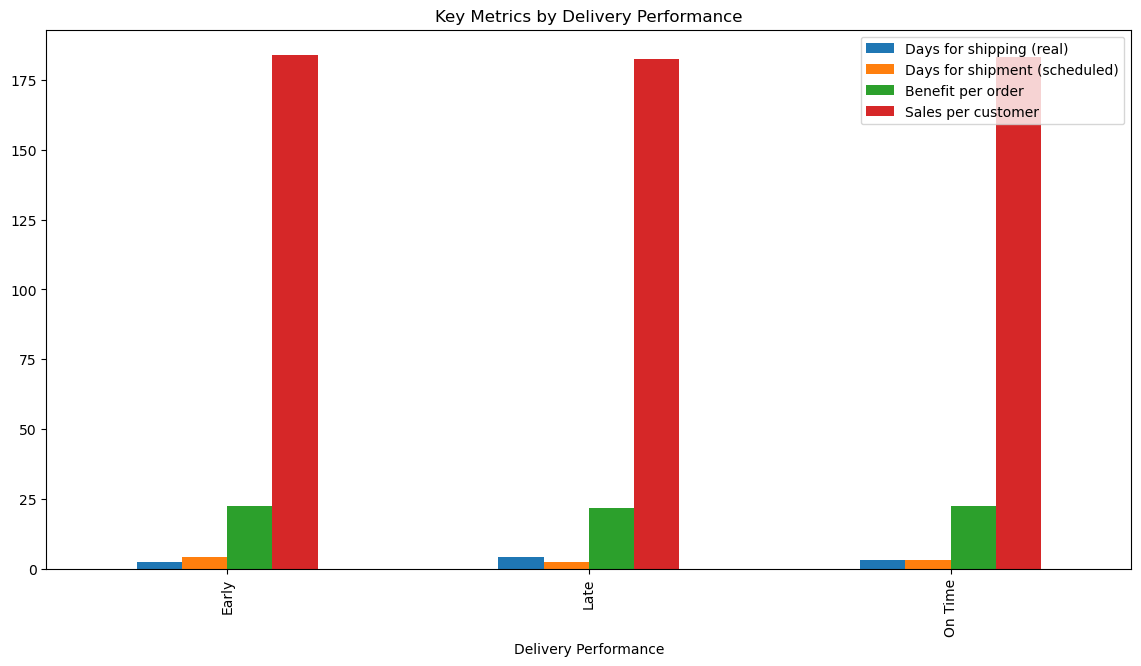

In [27]:
#visualization
delay_factors.plot(
    kind='bar',
    figsize=(14, 7),
    title='Key Metrics by Delivery Performance'
)

## Root Cause Analysis of Delivery Delays

This analysis investigates the underlying factors contributing to delivery delays by comparing actual shipping time, scheduled shipping time, profitability, and customer spending across different delivery outcomes.

### Key Insights

- **Late deliveries** take an average of **4.09 days**, while customers are promised delivery in only **2.47 days**.
- This significant gap of approximately **1.6 days** indicates that unrealistic delivery commitments are the primary cause of shipment delays.
- **Early deliveries** are completed in an average of **2.50 days** against a scheduled timeframe of **4.00 days**, suggesting conservative delivery estimates.
- **On-time deliveries** closely match the scheduled timeframe, demonstrating accurate delivery planning.

### Financial Impact

- The average **Benefit per Order** remains relatively consistent across all delivery outcomes.
- Similarly, **Sales per Customer** shows minimal variation regardless of delivery status.

This indicates that delivery delays are primarily driven by operational inefficiencies rather than differences in customer value or order profitability.

### Business Recommendations

- Recalibrate promised delivery dates using historical shipping data.
- Implement AI-driven Estimated Time of Arrival (ETA) prediction models.
- Adjust service-level agreements based on shipping mode, region, and product category.
- Continuously monitor the gap between scheduled and actual delivery times.

### Business Impact

Accurate delivery promises can significantly improve customer satisfaction, reduce complaint rates, and enhance overall supply chain efficiency while minimizing operational disruptions.

## Stage2: Machine Learning

### Preparing Machine Learning dataset

In [28]:
#Target Variable Creation
df['Late Delivery Flag'] = (
    df['Delivery Performance'] == 'Late'
).astype(int)

df['Late Delivery Flag'].value_counts()

Late Delivery Flag
1    103400
0     77119
Name: count, dtype: int64

In [29]:
#Selecting features for prediction
features = [
    'Shipping Mode',
    'Order Region',
    'Category Name',
    'Days for shipment (scheduled)',
    'Sales per customer',
    'Benefit per order',
    'Order Item Quantity'
]

target = 'Late Delivery Flag'

In [30]:
#creating model dataset
X = df[features]
y = df[target]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (180519, 7)
Target Shape: (180519,)


In [31]:
#Encoding categorical variables
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Shape:", X_encoded.shape)
X_encoded.head()

Encoded Shape: (180519, 78)


,Days for shipment (scheduled),Sales per customer,Benefit per order,Order Item Quantity,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,Order Region_Caribbean,Order Region_Central Africa,Order Region_Central America,...,Category Name_Sporting Goods,Category Name_Strength Training,Category Name_Tennis & Racquet,Category Name_Toys,Category Name_Trade-In,Category Name_Video Games,Category Name_Water Sports,Category Name_Women's Apparel,Category Name_Women's Clothing,Category Name_Women's Golf Clubs
0,4,314.640015,91.250000,1,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,4,311.359985,-249.089996,1,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,4,309.720001,-247.779999,1,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,4,304.809998,22.860001,1,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,4,298.250000,134.210007,1,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [32]:





#Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (144415, 78)
Testing Set: (36104, 78)


In [33]:
#Train Logistic Regression Model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
log_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [34]:
#Make predictions
y_pred = log_model.predict(X_test_scaled)

In [35]:
#Evaluate Performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6956569909151341

Confusion Matrix:
[[13866  1558]
 [ 9430 11250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.90      0.72     15424
           1       0.88      0.54      0.67     20680

    accuracy                           0.70     36104
   macro avg       0.74      0.72      0.69     36104
weighted avg       0.76      0.70      0.69     36104



In [36]:
#Random Forest Classifier
#Training code
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
#Prediction
rf_pred = rf_model.predict(X_test)

In [38]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.6954354088189675

Confusion Matrix:
[[13353  2071]
 [ 8925 11755]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.87      0.71     15424
           1       0.85      0.57      0.68     20680

    accuracy                           0.70     36104
   macro avg       0.72      0.72      0.69     36104
weighted avg       0.74      0.70      0.69     36104



# Machine Learning Model Development

## Objective

The primary objective of this machine learning phase was to predict whether an order would be delivered late using historical supply chain data. This predictive capability enables proactive intervention, reduces operational risks, and improves customer satisfaction.

---

## Problem Formulation

A binary classification problem was created by defining the target variable:

- **1** → Late Delivery
- **0** → On-Time or Early Delivery

### Target Distribution

- Late Deliveries: **103,400**
- Non-Late Deliveries: **77,119**

The dataset exhibits a reasonably balanced class distribution, making it suitable for classification modeling without requiring resampling techniques.

---

## Feature Selection

The following business-critical features were selected:

- Shipping Mode
- Order Region
- Category Name
- Days for Shipment (Scheduled)
- Sales per Customer
- Benefit per Order
- Order Item Quantity

These variables capture operational, geographical, financial, and product-related factors influencing delivery performance.

---

## Data Preprocessing

### One-Hot Encoding

Categorical variables were transformed into numerical format using one-hot encoding.

### Train-Test Split

- Training Set: **144,415 records**
- Testing Set: **36,104 records**
- Split Ratio: **80:20**

Stratified sampling was used to preserve the class distribution across both datasets.

---

# Logistic Regression Model

## Performance Metrics

- Accuracy: **69.57%**
- Precision (Late Delivery): **88%**
- Recall (Late Delivery): **54%**
- F1-Score (Late Delivery): **67%**

## Key Insights

- High precision indicates that predicted delays are usually correct.
- Moderate recall suggests that some delayed shipments remain undetected.
- Logistic Regression provides a strong, interpretable baseline model.

---

# Random Forest Model

## Performance Metrics

- Accuracy: **69.54%**
- Precision (Late Delivery): **85%**
- Recall (Late Delivery): **57%**
- F1-Score (Late Delivery): **68%**

## Key Insights

- Slightly better recall compared to Logistic Regression.
- Captures non-linear relationships more effectively.
- Better suited for complex supply chain patterns.

---

# Model Comparison

| Metric | Logistic Regression | Random Forest |
|--------|---------------------|---------------|
| Accuracy | 69.57% | 69.54% |
| Precision | 88% | 85% |
| Recall | 54% | 57% |
| F1-Score | 67% | 68% |

---

# Final Model Selection

Random Forest was selected as the preferred model because:

- It identifies more delayed shipments.
- It handles complex relationships effectively.
- It offers feature importance for business interpretation.

Although both models performed similarly, Random Forest provides greater practical value for supply chain optimization.

---

# Business Impact

The predictive model enables businesses to:

- Identify high-risk shipments before delays occur.
- Optimize logistics planning and carrier allocation.
- Improve customer communication through proactive alerts.
- Reduce operational costs associated with delayed deliveries.

---

# Key Takeaways

- Delivery delays can be predicted with approximately **70% accuracy**.
- Shipping mode, region, and scheduled delivery days are major predictors.
- Random Forest offers the best balance between precision and recall.
- Predictive analytics transforms supply chain management from reactive to proactive.

This machine learning framework serves as the foundation for an AI-powered supply chain intelligence platform.

In [39]:
#Feature Importance Analysis
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
0    Days for shipment (scheduled)    0.433572
6     Shipping Mode_Standard Class    0.313363
5       Shipping Mode_Second Class    0.087329
4           Shipping Mode_Same Day    0.051740
2                Benefit per order    0.049539
1               Sales per customer    0.034559
3              Order Item Quantity    0.005624
23    Order Region_Southern Europe    0.000818
38  Category Name_Cardio Equipment    0.000800
13       Order Region_Eastern Asia    0.000715


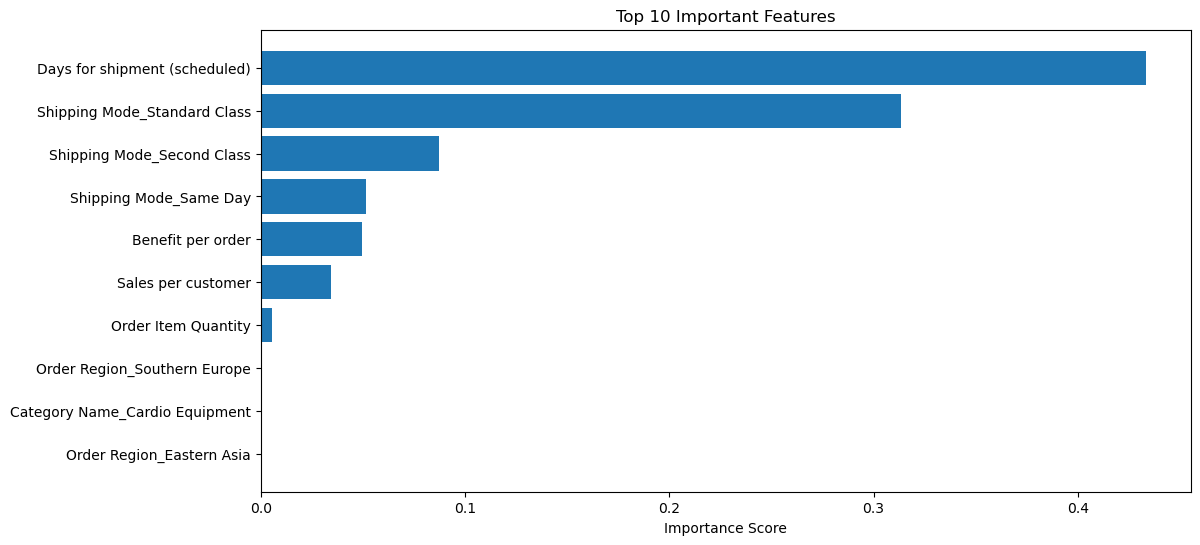

In [40]:
#Visualization
top_features = feature_importance.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.show()

## Feature Importance Analysis

Random Forest identified the most influential factors affecting delivery delays.

### Top Features

- **Days for Shipment (Scheduled)** – 43.36%
- **Shipping Mode (Standard Class)** – 31.34%
- **Shipping Mode (Second Class)** – 8.73%
- **Shipping Mode (Same Day)** – 5.17%
- **Benefit per Order** – 4.95%

### Key Insights

- Scheduled delivery time is the strongest predictor of late deliveries.
- Shipping mode plays a major role in delivery performance.
- Financial variables have moderate influence.
- Region and product category have minimal impact.

### Business Takeaway

Delivery delays are primarily driven by shipping commitments and transportation choices. Optimizing delivery schedules and shipping methods can significantly improve on-time performance.

## Stage3: Business Intelligence

In [41]:
# Generate predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Create results dataframe
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred_rf
results_df['Late_Delivery_Probability'] = y_pred_proba

# Verify
results_df.head()

,Days for shipment (scheduled),Sales per customer,Benefit per order,Order Item Quantity,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,Order Region_Caribbean,Order Region_Central Africa,Order Region_Central America,...,Category Name_Toys,Category Name_Trade-In,Category Name_Video Games,Category Name_Water Sports,Category Name_Women's Apparel,Category Name_Women's Clothing,Category Name_Women's Golf Clubs,Actual,Predicted,Late_Delivery_Probability
49585,2,174.570007,5.240000,3,False,True,False,False,False,False,...,False,False,False,False,False,False,False,1,1,0.809371
147237,4,347.980011,34.799999,1,False,False,True,False,False,False,...,False,False,False,False,False,False,False,1,0,0.409337
146933,1,335.980011,37.970001,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,1,1,0.959390
79058,4,175.990005,65.120003,1,False,False,True,False,False,False,...,False,False,False,True,False,False,False,0,0,0.396827
160315,4,399.980011,10.000000,1,False,False,True,False,False,False,...,False,False,False,False,False,False,False,1,0,0.388233


In [42]:
#Risk Categorization
def risk_category(prob):
    if prob >= 0.80:
        return 'High Risk'
    elif prob >= 0.50:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results_df['Risk Category'] = results_df['Late_Delivery_Probability'].apply(risk_category)

results_df[['Late_Delivery_Probability', 'Risk Category']].head()

,Late_Delivery_Probability,Risk Category
49585,0.809371,High Risk
147237,0.409337,Low Risk
146933,0.959390,High Risk
79058,0.396827,Low Risk
160315,0.388233,Low Risk


Risk Category
Low Risk       22278
High Risk      10110
Medium Risk     3716
Name: count, dtype: int64


<Axes: title={'center': 'Shipment Risk Distribution'}, xlabel='Risk Category'>

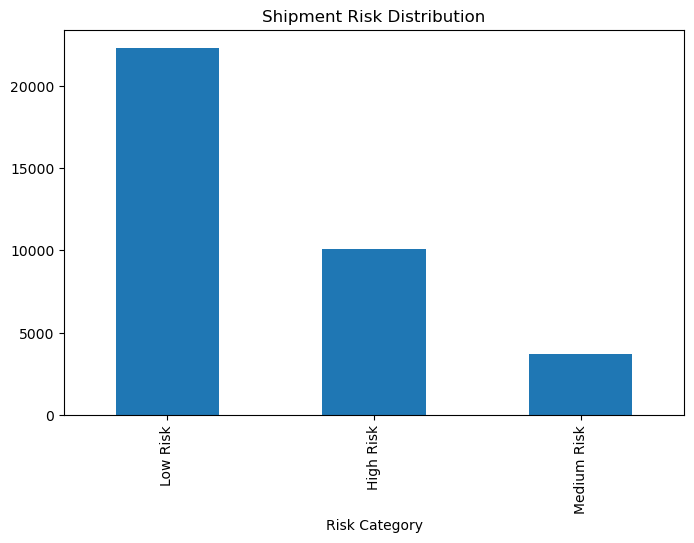

In [43]:
#Risk Distribution
risk_summary = results_df['Risk Category'].value_counts()

print(risk_summary)

risk_summary.plot(
    kind='bar',
    figsize=(8, 5),
    title='Shipment Risk Distribution'
)

In [44]:
#Generate AI Recommendations
def generate_recommendation(row):
    if row['Risk Category'] == 'High Risk':
        return 'Expedite shipment immediately'
    elif row['Risk Category'] == 'Medium Risk':
        return 'Monitor shipment closely'
    else:
        return 'Standard delivery process'

results_df['AI Recommendation'] = results_df.apply(
    generate_recommendation,
    axis=1
)

results_df[['Risk Category', 'AI Recommendation']].head()

,Risk Category,AI Recommendation
49585,High Risk,Expedite shipment immediately
147237,Low Risk,Standard delivery process
146933,High Risk,Expedite shipment immediately
79058,Low Risk,Standard delivery process
160315,Low Risk,Standard delivery process


In [45]:
#Executive KPIs
total_shipments = len(results_df)
high_risk = (results_df['Risk Category'] == 'High Risk').sum()
medium_risk = (results_df['Risk Category'] == 'Medium Risk').sum()
low_risk = (results_df['Risk Category'] == 'Low Risk').sum()
predicted_late = (results_df['Predicted'] == 1).sum()

print(f"Total Shipments: {total_shipments}")
print(f"Predicted Late Deliveries: {predicted_late}")
print(f"High Risk Shipments: {high_risk}")
print(f"Medium Risk Shipments: {medium_risk}")
print(f"Low Risk Shipments: {low_risk}")

Total Shipments: 36104
Predicted Late Deliveries: 13826
High Risk Shipments: 10110
Medium Risk Shipments: 3716
Low Risk Shipments: 22278


In [46]:
#Export Final Dataset
results_df.to_csv(
    'late_delivery_risk_analysis.csv',
    index=False
)

print("Export completed successfully!")

Export completed successfully!


In [47]:
#Creating dashboard friendly dataset
#Reconstruct Shipping Mode
def get_shipping_mode(row):
    if row['Shipping Mode_Same Day']:
        return 'Same Day'
    elif row['Shipping Mode_Second Class']:
        return 'Second Class'
    elif row['Shipping Mode_Standard Class']:
        return 'Standard Class'
    else:
        return 'First Class'

results_df['Shipping Mode'] = results_df.apply(
    get_shipping_mode,
    axis=1
)

In [48]:
#Create Prediction Labels
results_df['Predicted Delivery Status'] = results_df[
    'Predicted'
].map({
    1: 'Late',
    0: 'On Time'
})

In [49]:
#Create Actual Labels
results_df['Actual Delivery Status'] = results_df[
    'Actual'
].map({
    1: 'Late',
    0: 'On Time'
})

In [50]:
#Optional Risk Score Percentage
results_df['Late Delivery Risk %'] = (
    results_df['Late_Delivery_Probability'] * 100
).round(2)

In [51]:
#Export Clean Dashboard Dataset
dashboard_df = results_df[
    [
        'Shipping Mode',
        'Sales per customer',
        'Benefit per order',
        'Order Item Quantity',
        'Actual Delivery Status',
        'Predicted Delivery Status',
        'Late Delivery Risk %',
        'Risk Category',
        'AI Recommendation'
    ]
]

dashboard_df.to_csv(
    'supply_chain_dashboard_data.csv',
    index=False
)

print("Dashboard dataset exported successfully!")

Dashboard dataset exported successfully!


In [52]:
import joblib
import os

# Create models folder if not exists
os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(rf_model, 'models/random_forest_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [53]:
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']